# Isaac Balam Rodriguez Arellano

# Collen Foster Ellis

# TP14 (Student version): Internet Graph Structure

We can use the following libraries.

In [1]:
import matplotlib.pyplot as plt
import math
import sys
import random
import queue
print(sys.version)

3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]


This lab is a little different from the others: I don't give you detailed instructions to follow, but only what we want to obtain, and you need to find out how to do this, using the tools and codes that we have throughout the Graph course of GaN.

We want to replicate the observations reported in *Sampling Biases in IP Topology Measurements* by Lakhina et al. Precisely:

- Generate a graph with

    - a homogeneous degree distribution ($n \simeq 100,000$ , $m \simeq 750,000$),

    - a power-law degree distribution ($n \simeq 100,000$ , $m \simeq 200,000$).

These graphs will be refered to as the *original graphs* $ G_{o,homo} $ and $ G_{o,pl} $ (or collectively simply $ G_o $) in what follows.

- Simulate traceroutes using the *restricted BFS* version seen in the course. You will use $k = 1$ source, and 1000 destinations (chosen randomly) first, then proceed $k = 5, 10$ sources.

By putting together the results of the simulated traceroutes from different sources (chosen randomly), we obtain a map of the original graph that we call the sample graph $ G_s(k) $, where $k$ is the number of simulated traceroutes brought together. 

For instance the sample graph obtained from $ G_{o,homo} $ with $ k=5 $ sources will be denoted $ G_{s,homo}(5) $

- For both original graphs $G_o$, compare the degree distributions in $ G_o $ to what you obtain in the simulated samples $ G_s $, in particular see if you can make the same observation as in the course.

- Plot the inverse cumulative distribution of the degree in $G_o$ and compare it to the inverse cumulative distribution in the corresponding $ G_s $ in the different cases, compare to what we have seen in the course and comment.

- Plot the fraction of the edges observed as a function of the number of hops from the source, compare to what we have seen in the course and comment.  

In [2]:
def num_edges(adj):
    return sum(len(s) for s in adj) // 2


def degree_counts(adj):
    counts = {}
    for s in adj:
        d = len(s)
        counts[d] = counts.get(d, 0) + 1
    return counts


def ccdf_from_counts(counts):
    ks = sorted(counts)
    n = sum(counts.values())
    tail = 0
    out = []
    for k in reversed(ks):
        tail += counts[k]
        out.append((k, tail / n))
    return list(reversed(out))


def adj_from_edges(n, edges):
    adj = [set() for _ in range(n)]
    for u, v in edges:
        adj[u].add(v)
        adj[v].add(u)
    return adj


def make_homogeneous_graph(n=100_000, m=750_000, seed=0):
    random.seed(seed)
    adj = [set() for _ in range(n)]
    edges = 0
    while edges < m:
        u = random.randrange(n)
        v = random.randrange(n)
        if u == v or v in adj[u]:
            continue
        adj[u].add(v)
        adj[v].add(u)
        edges += 1
    return adj


def make_powerlaw_graph(n=100_000, m0=2, seed=1):
    random.seed(seed)
    adj = [set() for _ in range(n)]
    adj[0].add(1)
    adj[1].add(0)
    targets = [0, 1]
    for new in range(2, n):
        chosen = set()
        while len(chosen) < m0:
            chosen.add(random.choice(targets))
        for v in chosen:
            adj[new].add(v)
            adj[v].add(new)
        targets.extend([new] * m0)
        for v in chosen:
            targets.append(v)
    return adj


In [3]:
def restricted_bfs_tree(adj, source):
    parent = {source: None}
    dist = {source: 0}
    q = queue.Queue()
    q.put(source)
    while not q.empty():
        u = q.get()
        neigh = list(adj[u])
        random.shuffle(neigh)
        for v in neigh:
            if v not in parent:
                parent[v] = u
                dist[v] = dist[u] + 1
                q.put(v)
    return parent, dist


def pick_destinations(n, source, num_dest):
    dests = set()
    while len(dests) < num_dest:
        v = random.randrange(n - 1)
        if v >= source:
            v += 1
        dests.add(v)
    return list(dests)


def traceroute_edges(adj, source, destinations):
    parent, dist = restricted_bfs_tree(adj, source)
    edges = set()
    edges_by_hop = {}
    for dst in destinations:
        if dst not in parent:
            continue
        v = dst
        while parent[v] is not None:
            u = parent[v]
            a, b = (u, v) if u < v else (v, u)
            if (a, b) not in edges:
                edges.add((a, b))
                hop = max(dist[u], dist[v])
                edges_by_hop[hop] = edges_by_hop.get(hop, 0) + 1
            v = u
    return edges, edges_by_hop


def sample_graph(adj, k, num_dest=1000, seed=0):
    random.seed(seed)
    n = len(adj)
    sources = random.sample(range(n), k)
    all_edges = set()
    hop_counts = {}
    for s in sources:
        dests = pick_destinations(n, s, num_dest)
        edges, hops = traceroute_edges(adj, s, dests)
        all_edges.update(edges)
        for h, c in hops.items():
            hop_counts[h] = hop_counts.get(h, 0) + c
    return all_edges, hop_counts


Homo edges: 750000
PL edges: 199997


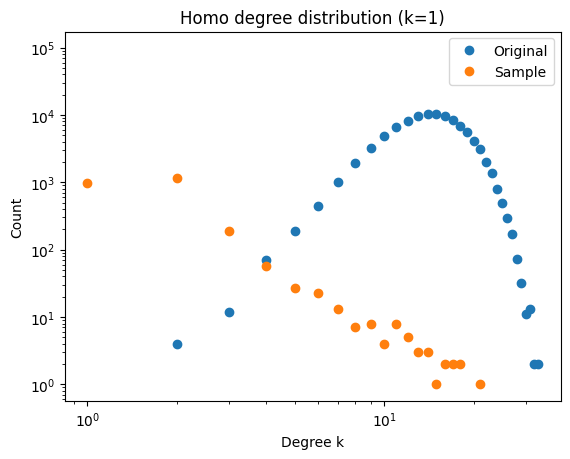

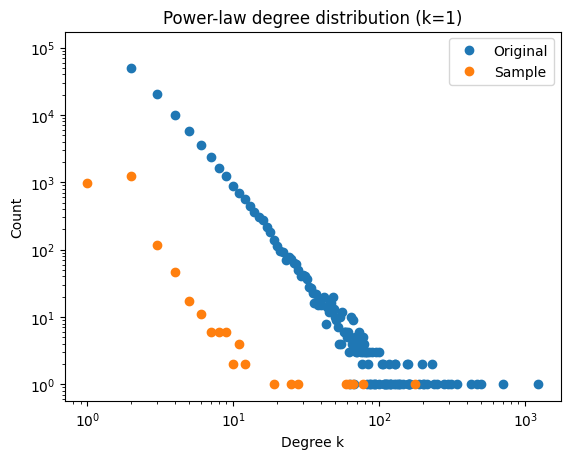

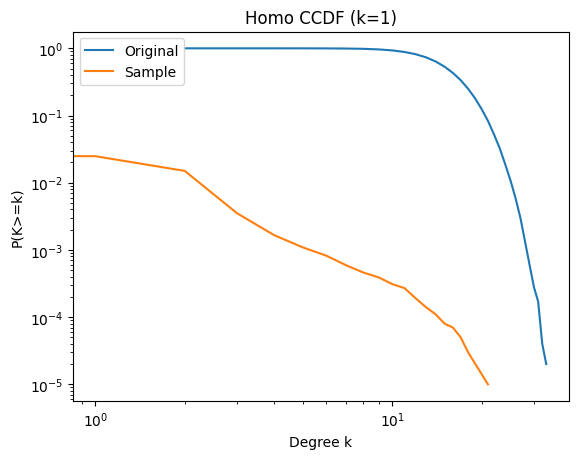

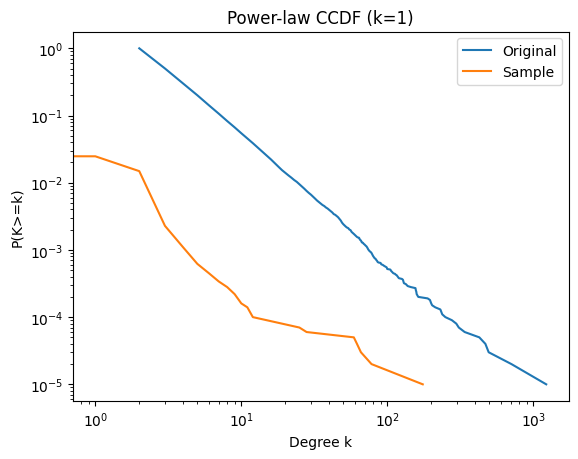

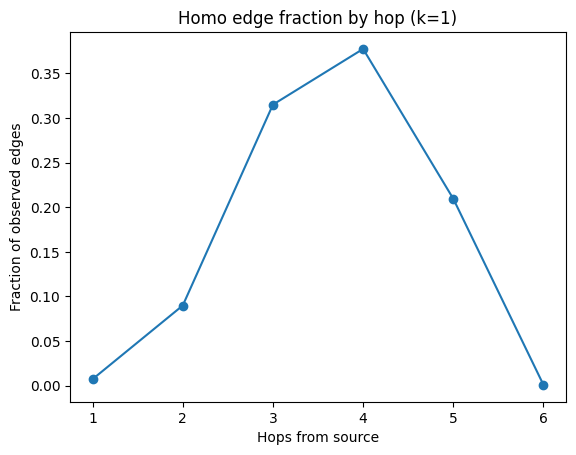

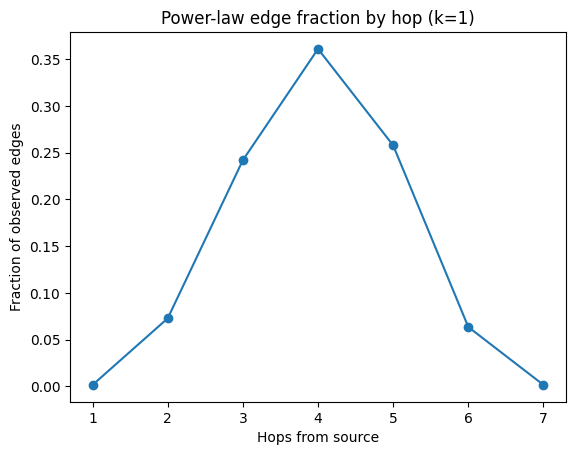

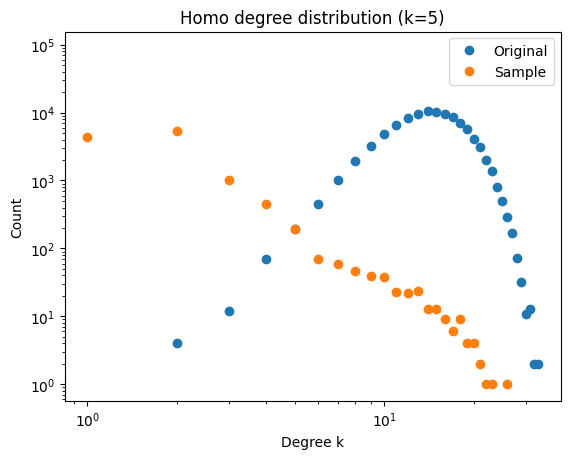

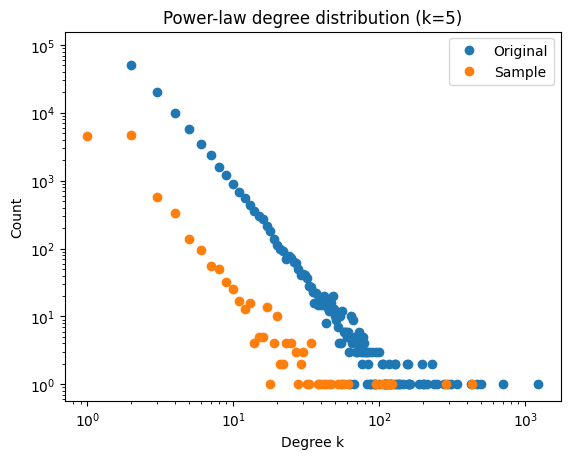

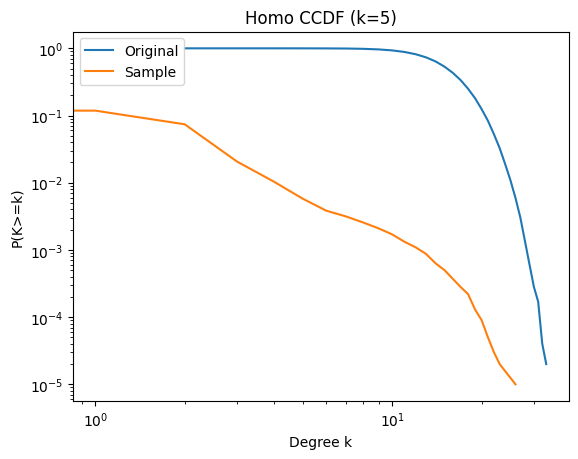

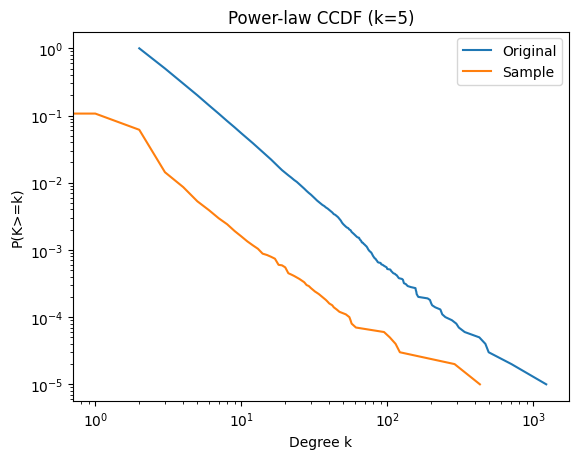

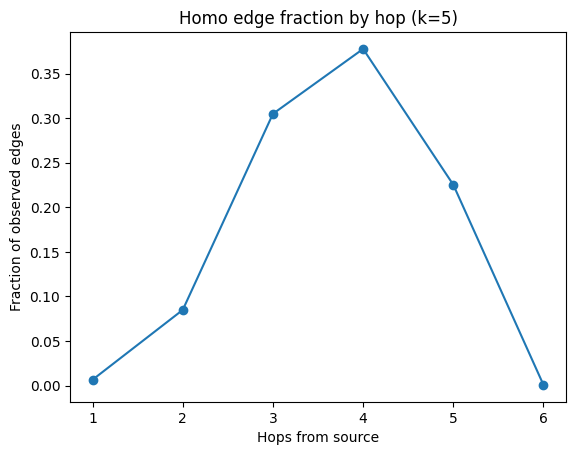

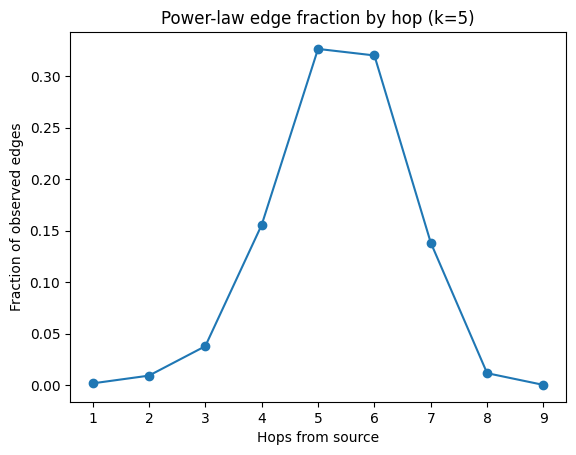

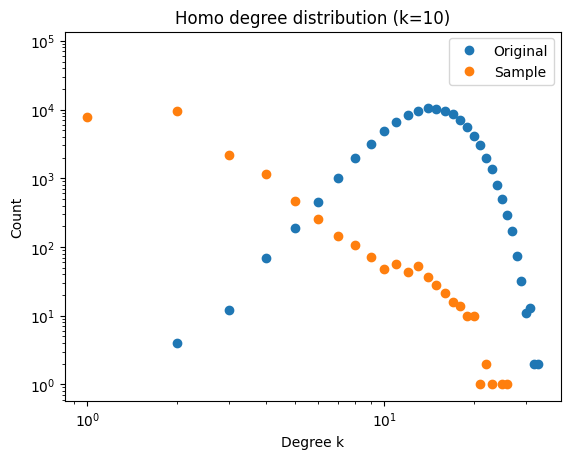

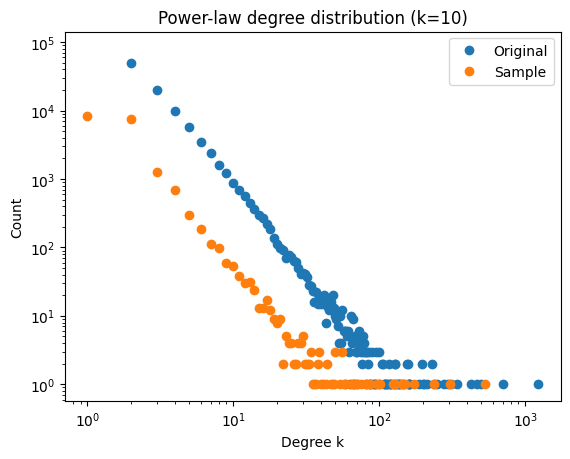

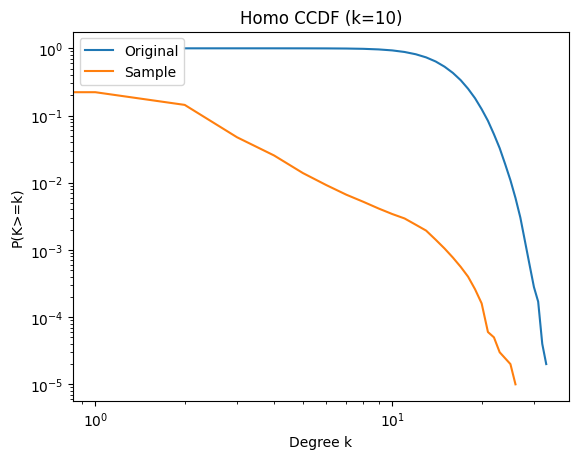

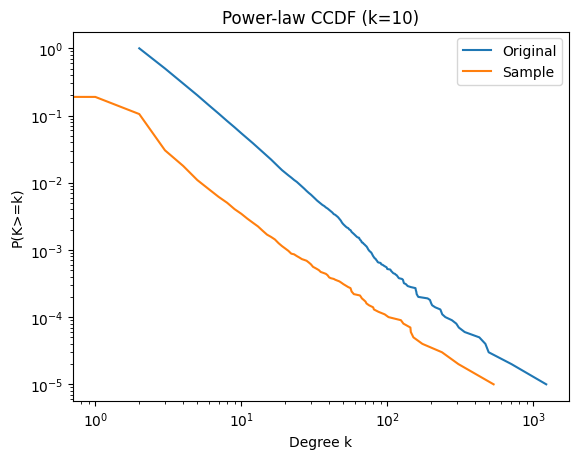

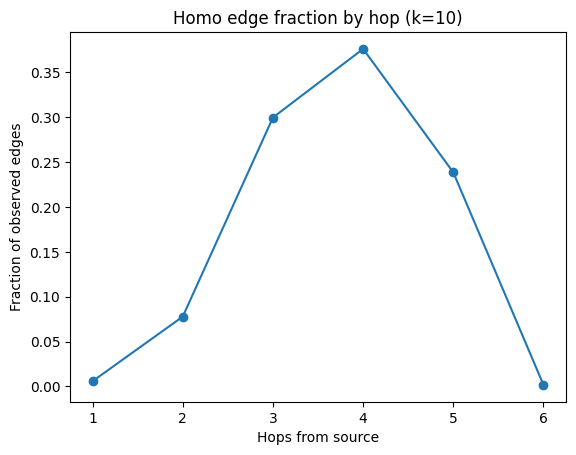

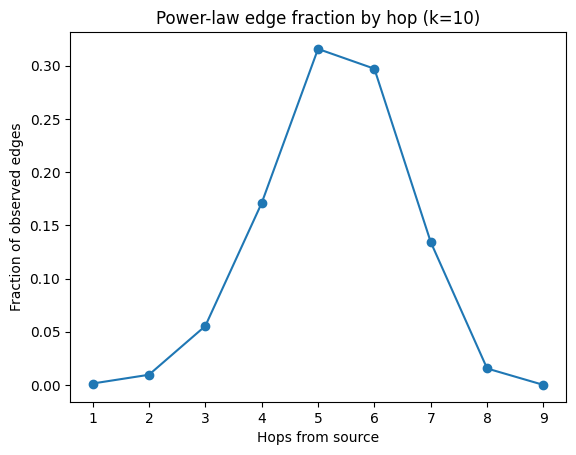

In [4]:
def plot_degree_hist(adj_o, adj_s, title):
    o_counts = degree_counts(adj_o)
    s_counts = degree_counts(adj_s)
    plt.figure()
    plt.loglog(list(o_counts.keys()), list(o_counts.values()), "o", label="Original")
    plt.loglog(list(s_counts.keys()), list(s_counts.values()), "o", label="Sample")
    plt.xlabel("Degree k")
    plt.ylabel("Count")
    plt.title(title)
    plt.legend()


def plot_degree_ccdf(adj_o, adj_s, title):
    o_ccdf = ccdf_from_counts(degree_counts(adj_o))
    s_ccdf = ccdf_from_counts(degree_counts(adj_s))
    plt.figure()
    plt.loglog([k for k, _ in o_ccdf], [p for _, p in o_ccdf], label="Original")
    plt.loglog([k for k, _ in s_ccdf], [p for _, p in s_ccdf], label="Sample")
    plt.xlabel("Degree k")
    plt.ylabel("P(K>=k)")
    plt.title(title)
    plt.legend()


def plot_edge_fraction_by_hop(hop_counts, title):
    hops = sorted(hop_counts)
    total = sum(hop_counts.values())
    fracs = [hop_counts[h] / total for h in hops]
    plt.figure()
    plt.plot(hops, fracs, "o-")
    plt.xlabel("Hops from source")
    plt.ylabel("Fraction of observed edges")
    plt.title(title)


# Generate original graphs
G_homo = make_homogeneous_graph(n=100_000, m=750_000, seed=42)
G_pl = make_powerlaw_graph(n=100_000, m0=2, seed=43)

print("Homo edges:", num_edges(G_homo))
print("PL edges:", num_edges(G_pl))

# Sample graphs for k = 1, 5, 10
for k in [1, 5, 10]:
    edges_h, hops_h = sample_graph(G_homo, k=k, num_dest=1000, seed=100 + k)
    edges_p, hops_p = sample_graph(G_pl, k=k, num_dest=1000, seed=200 + k)

    Gs_h = adj_from_edges(len(G_homo), edges_h)
    Gs_p = adj_from_edges(len(G_pl), edges_p)

    plot_degree_hist(G_homo, Gs_h, f"Homo degree distribution (k={k})")
    plot_degree_hist(G_pl, Gs_p, f"Power-law degree distribution (k={k})")

    plot_degree_ccdf(G_homo, Gs_h, f"Homo CCDF (k={k})")
    plot_degree_ccdf(G_pl, Gs_p, f"Power-law CCDF (k={k})")

    plot_edge_fraction_by_hop(hops_h, f"Homo edge fraction by hop (k={k})")
    plot_edge_fraction_by_hop(hops_p, f"Power-law edge fraction by hop (k={k})")

plt.show()
